# Post-process trip data

## Install and import packages

In [1]:
#!pip install --upgrade seaborn
!pip install plotly

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import numpy as np
import pandas as pd

## Utils

In [3]:
# Set SAVE equals to True, in order to Save cleaned trip data
SAVE = False

if SAVE:
    output_dir = f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/'
    file_path_csv = os.path.join(output_dir, f'EV_generated_data__trip_cleaned.csv')
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

## Data Inspection and Cleaning

### Load Synthetic Data

In [4]:
# Load trip data
#######trip_data = pd.read_csv('./Data_saved/kl_scheduling/allRows_vin2/Generated_data_NO_shuffle/EV_generated_data.csv')

number = 900
trip_data = pd.read_csv(f'./Data_saved/kl_scheduling/allRows_vin2/Generated_data_0_001EVpenalty/Generated_data/epoch_{number}/EV_generated_data_{number}.csv')
# Add a column id to keep the number of the row
trip_data['id'] = trip_data.index
trip_data = trip_data[trip_data['event'] == 0].reset_index(drop=True)
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12066 entries, 0 to 12065
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event             12066 non-null  int64  
 1   charge_mode       12066 non-null  int64  
 2   duration_minutes  12066 non-null  float64
 3   km_driven         12066 non-null  float64
 4   charge            12066 non-null  float64
 5   id                12066 non-null  int64  
dtypes: float64(3), int64(3)
memory usage: 565.7 KB


In [5]:
trip_data.head(10)

,event,charge_mode,duration_minutes,km_driven,charge,id
0,0,0,37.226245,17.283895,-3.819808,1
1,0,0,82.138858,35.239328,-7.723593,2
2,0,0,13.227310,10.201922,-0.897837,3
3,0,0,36.760313,25.046932,-2.974316,4
4,0,0,55.845177,23.236380,-4.608045,5
5,0,0,18.581636,13.931723,-0.593993,6
6,0,0,79.671750,59.871211,-10.852464,7
7,0,0,22.443127,13.518031,-2.629422,8
8,0,0,148.129735,74.939310,-13.497396,9
9,0,0,32.480777,10.274106,1.983025,10


### Data description

In [6]:
# Remove duplicates
init_len = len(trip_data)
trip_data = trip_data.drop_duplicates()

# Print how many records remain
print(f"Number of duplicates removed: {init_len - len(trip_data)}")

Number of duplicates removed: 0


In [7]:
# Check for missing values and print records with them
nan_count = trip_data.isna().sum()
print("| Features | NaN-counter |")
print(nan_count)
print("|----------|-------------|")

records_with_nan = trip_data[trip_data.isna().any(axis=1)]

length = len(records_with_nan)
if length > 0:
    print("\n🔍 Records with missing values:\n")
    print(records_with_nan.head(length))

| Features | NaN-counter |
event               0
charge_mode         0
duration_minutes    0
km_driven           0
charge              0
id                  0
dtype: int64
|----------|-------------|


In [8]:
# main statistics of the dataset
trip_data['delta_soc'] = trip_data['charge']
print("Statistics of the dataset:")
trip_data[['km_driven', 'delta_soc']].describe().T

Statistics of the dataset:


,count,mean,std,min,25%,50%,75%,max
km_driven,12066.0,39.070994,37.701643,2.218351,11.703015,22.424669,55.298143,204.288635
delta_soc,12066.0,-5.873171,8.723721,-35.333044,-10.586282,-3.474530,-0.937333,27.237682


In [9]:
# Add discharge
trip_data['discharge'] = - trip_data['charge']


# Add avg_speed in km/h 
trip_data['avg_speed'] = np.where(
    trip_data['duration_minutes'] > 0,
    (trip_data['km_driven']) / (trip_data['duration_minutes'] / 60),
    0
)

# Add km_per_perc_of_battery and discharge_per_km 
trip_data['km_per_perc_of_battery'] = trip_data.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)
trip_data['discharge_per_km'] = trip_data.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)

# Print statistics
print('Statistics before post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics before post-processing

📊 Statistics on driven km:
 count    12066.000000
mean        39.070994
std         37.701643
min          2.218351
25%         11.703015
50%         22.424669
75%         55.298143
max        204.288635
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    12066.000000
mean         5.873171
std          8.723721
min        -27.237682
25%          0.937333
50%          3.474530
75%         10.586282
max         35.333044
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    12066.000000
mean        39.103258
std         11.831057
min          4.194067
25%         34.751894
50%         41.771785
75%         46.157327
max         88.925826
Name: avg_speed, dtype: float64
99th percentile of average speed: 62.70 km/h

🛢️ Statistics on km per percentage of battery:
 count    12066.000000
mean         4.110043
std        321.364292
min     -22960.162236
25%          4.527825
50%          5.378396
75%          7.065341
max

### Identify and remove anomalous records

In [10]:
# Identify snapshot records (data with no changes in soc, odo, and duration)
snapshot_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] == 0)]

length = snapshot_records.shape[0]
print(f"Number of snapshot records: {length}")
if length > 0:
    snapshot_records.head(length)

Number of snapshot records: 0


In [11]:
# Remove snapshot records
trip_data = trip_data.drop(snapshot_records.index).reset_index(drop=True)

In [12]:
# Identify records with negative duration
negative_duration_records = trip_data[(trip_data['duration_minutes'] <= 0)]

length = negative_duration_records.shape[0]
print(f"Number of records with negative duration: {length}")
if length > 0:  
    negative_duration_records.head(length)

Number of records with negative duration: 0


In [13]:
# Remove records with negative duration
trip_data = trip_data.drop(negative_duration_records.index).reset_index(drop=True)

In [14]:
# Identify stationary records (data with no changes in soc, odo, but positive duration)
stationary_records = trip_data[(trip_data['charge'] == 0) & (trip_data['km_driven'] == 0) & (trip_data['duration_minutes'] > 0)]

length = stationary_records.shape[0]
print(f"Number of stationary records: {length}")
if length > 0:
    stationary_records.head(length)

Number of stationary records: 0


In [15]:
# Remove stationary records
trip_data = trip_data.drop(stationary_records.index).reset_index(drop=True)

In [16]:
# Identify records with (end_soc) [%] > (soc + 1) [%]   
anomalous_soc_records = trip_data[(trip_data['charge'] > 1)]

length = anomalous_soc_records.shape[0]
print(f"Number of anomalous soc records: {length}")
anomalous_soc_records.head(length)

Number of anomalous soc records: 1622


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
9,0,0,32.480777,10.274106,1.983025,10,1.983025,-1.983025,18.978805,-5.181026,-0.193012
12,0,0,13.257598,7.320306,9.465801,13,9.465801,-9.465801,33.129559,-0.773342,-1.293088
13,0,0,10.504164,7.959931,2.892109,14,2.892109,-2.892109,45.467288,-2.752293,-0.363333
26,0,0,22.875406,3.434948,2.325580,35,2.325580,-2.325580,9.009540,-1.477028,-0.677035
58,0,0,18.620382,4.081306,5.773479,83,5.773479,-5.773479,13.151092,-0.706906,-1.414616
...,...,...,...,...,...,...,...,...,...,...,...
12044,0,0,18.335464,16.732468,5.221789,17379,5.221789,-5.221789,54.754441,-3.204356,-0.312075
12045,0,0,10.370520,9.543756,1.430011,17382,1.430011,-1.430011,55.216651,-6.673903,-0.149837
12052,0,0,20.921042,6.366470,5.066220,17392,5.066220,-5.066220,18.258564,-1.256651,-0.795766
12057,0,0,21.588920,6.494915,4.831430,17398,4.831430,-4.831430,18.050688,-1.344305,-0.743879


In [17]:
# Remove anomalous soc records
trip_data = trip_data.drop(anomalous_soc_records.index).reset_index(drop=True)

In [18]:
# Identify anomalous movement records (end_odo < odo)
anomalous_movement_records = trip_data[(trip_data['km_driven'] < 0)]

length = anomalous_movement_records.shape[0]
print(f"Number of anomalous movement records: {length}")
if length > 0:
    anomalous_movement_records.head(length)

Number of anomalous movement records: 0


In [19]:
# Remove anomalous movement records
trip_data = trip_data.drop(anomalous_movement_records.index).reset_index(drop=True)

In [20]:
# Identify records with high average speed 
#######################
SPEED_THRESHOLD = 130 #
#######################

anomalous_speed_records = trip_data[(trip_data['avg_speed'] > SPEED_THRESHOLD)]

length = anomalous_speed_records.shape[0]
print(f"Number of records with avg_speed > {SPEED_THRESHOLD} km/h: {length}")
anomalous_speed_records.head(length)

Number of records with avg_speed > 130 km/h: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [21]:
# Remove anomalous speed records
trip_data = trip_data.drop(anomalous_speed_records.index).reset_index(drop=True)

In [22]:
# Identify anomalous records with high discharge per km
############################
MAX_DISCHARGE_PER_KM = 0.9 #
############################

anomalous_discharge_records = trip_data[(trip_data['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")

anomalous_discharge_records.head(length)

Number of anomalous discharge records: 0


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km


In [23]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [24]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 481


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
3699,0,0,10.088230,8.873972,-0.000378,6022,-0.000378,0.000378,52.778170,23496.432464,0.000043
9782,0,0,17.396089,12.995770,-0.006073,16283,-0.006073,0.006073,44.823077,2139.861457,0.000467
5444,0,0,17.290590,12.536321,-0.005940,9001,-0.005940,0.005940,43.502230,2110.507750,0.000474
4569,0,0,10.930390,9.534638,-0.005407,7522,-0.005407,0.005407,52.338324,1763.374320,0.000567
1173,0,0,204.054358,14.905437,-0.011261,1911,-0.011261,0.011261,4.382784,1323.661701,0.000755
...,...,...,...,...,...,...,...,...,...,...,...
5108,0,0,11.049146,9.052563,-0.448399,8425,-0.448399,0.448399,49.157985,20.188612,0.049533
3318,0,0,14.740872,12.056831,-0.598148,5393,-0.598148,0.598148,49.075105,20.156934,0.049611
7657,0,0,15.382165,9.894870,-0.491008,12724,-0.491008,0.491008,38.596140,20.152175,0.049622
373,0,0,12.371252,10.220470,-0.507503,613,-0.507503,0.507503,49.568809,20.138744,0.049656


In [25]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [26]:
# Identify anomalous records with low km per percentage of battery discharge 
############################
MIN_KM_PER_DISCHARGE = -10 #
############################

anomalous_discharge_records = trip_data[trip_data['km_per_perc_of_battery'] < MIN_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)

Number of anomalous discharge records: 377


,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
578,0,0,10.156538,9.541330,0.952055,994,0.952055,-0.952055,56.365648,-10.021829,-0.099782
2809,0,0,15.516948,8.469185,0.844140,4804,0.844140,-0.844140,32.748135,-10.032917,-0.099672
602,0,0,18.308978,7.286472,0.714925,1047,0.714925,-0.714925,23.878359,-10.191938,-0.098117
2353,0,0,11.713903,7.678715,0.750430,4014,0.750430,-0.750430,39.331289,-10.232414,-0.097729
9009,0,0,15.648474,9.919326,0.966127,15721,0.966127,-0.966127,38.033071,-10.267103,-0.097398
...,...,...,...,...,...,...,...,...,...,...,...
6552,0,0,8.431382,7.375481,0.002961,11386,0.002961,-0.002961,52.485921,-2490.571116,-0.000402
5585,0,0,8.807335,7.891161,0.002670,9675,0.002670,-0.002670,53.758558,-2955.574758,-0.000338
6914,0,0,23.899668,18.410980,0.004802,12019,0.004802,-0.004802,46.220677,-3834.361102,-0.000261
6971,0,0,41.954913,11.889094,0.001179,12120,0.001179,-0.001179,17.002672,-10080.350215,-0.000099


In [27]:
# Remove anomalous discharge records
trip_data = trip_data.drop(anomalous_discharge_records.index).reset_index(drop=True)

In [28]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9586 entries, 0 to 9585
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9586 non-null   int64  
 1   charge_mode             9586 non-null   int64  
 2   duration_minutes        9586 non-null   float64
 3   km_driven               9586 non-null   float64
 4   charge                  9586 non-null   float64
 5   id                      9586 non-null   int64  
 6   delta_soc               9586 non-null   float64
 7   discharge               9586 non-null   float64
 8   avg_speed               9586 non-null   float64
 9   km_per_perc_of_battery  9586 non-null   float64
 10  discharge_per_km        9586 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 823.9 KB


In [29]:
# Print statistics
print('Statistics after post-processing\n')
print("📊 Statistics on driven km:\n", trip_data['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data['discharge'].describe())
print("\n🚗 Statistics on average speed:\n", trip_data['avg_speed'].describe())
p99_speed = trip_data['avg_speed'].quantile(0.99)
print(f"99th percentile of average speed: {p99_speed:.2f} km/h")
print("\n🛢️ Statistics on km per percentage of battery:\n", trip_data['km_per_perc_of_battery'].describe())
print("\n🔋 Statistics on discharge per km:\n", trip_data['discharge_per_km'].describe())

Statistics after post-processing

📊 Statistics on driven km:
 count    9586.000000
mean       46.513729
std        38.917033
min         3.490210
25%        16.153646
50%        31.734915
75%        67.034754
max       204.288635
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    9586.000000
mean        8.426669
std         7.591897
min        -0.999384
25%         2.334448
50%         5.483534
75%        13.129717
max        35.333044
Name: discharge, dtype: float64

🚗 Statistics on average speed:
 count    9586.000000
mean       38.934292
std        10.276285
min         4.473561
25%        35.717817
50%        41.569805
75%        45.452385
max        63.960549
Name: avg_speed, dtype: float64
99th percentile of average speed: 54.80 km/h

🛢️ Statistics on km per percentage of battery:
 count    9586.000000
mean        6.602301
std         3.048316
min        -9.928597
25%         4.990259
50%         5.619475
75%         7.241422
max        19.997836
Name: km_per_p

## Data Visualization and Comparative Analysis

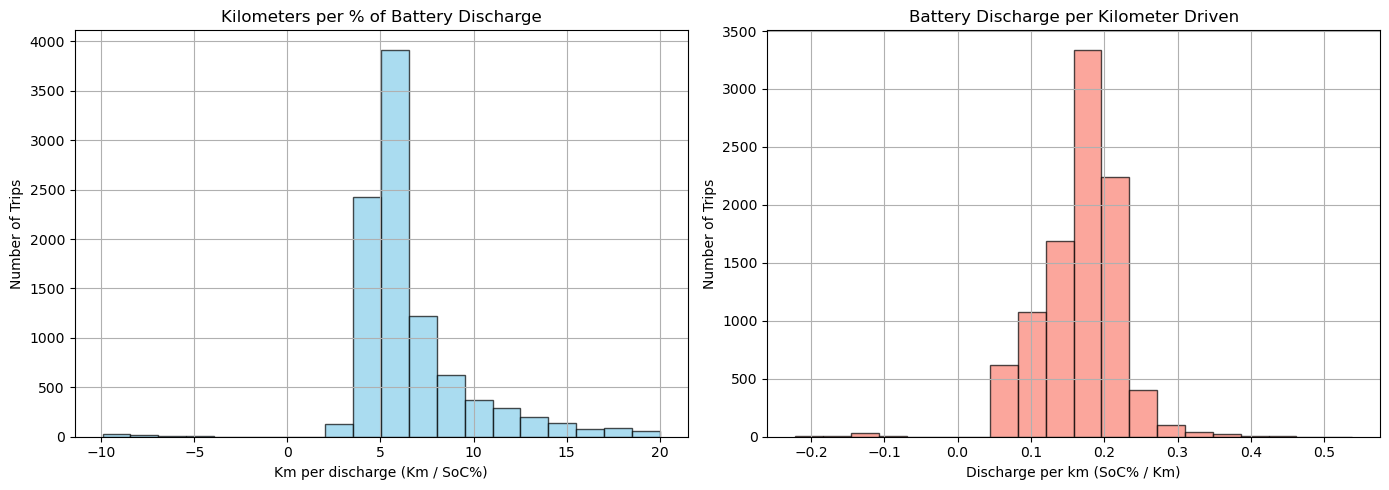

In [30]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kilometers per % battery
axes[0].hist(
    trip_data['km_per_perc_of_battery'],
    bins=20,
    alpha=0.7,
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Kilometers per % of Battery Discharge')
axes[0].set_xlabel('Km per discharge (Km / SoC%)')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True)

# Discharge per km
axes[1].hist(
    trip_data['discharge_per_km'],
    bins=20,
    alpha=0.7,
    color='salmon',
    edgecolor='black'
)
axes[1].set_title('Battery Discharge per Kilometer Driven')
axes[1].set_xlabel('Discharge per km (SoC% / Km)')
axes[1].set_ylabel('Number of Trips')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [31]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
0,0,0,37.226245,17.283895,-3.819808,1,-3.819808,3.819808,27.857597,4.524807,0.221004
1,0,0,82.138858,35.239328,-7.723593,2,-7.723593,7.723593,25.741284,4.562556,0.219175
2,0,0,13.227310,10.201922,-0.897837,3,-0.897837,0.897837,46.276630,11.362780,0.088007
3,0,0,36.760313,25.046932,-2.974316,4,-2.974316,2.974316,40.881478,8.421072,0.118750
4,0,0,55.845177,23.236380,-4.608045,5,-4.608045,4.608045,24.965143,5.042568,0.198312


In [32]:
max_km = trip_data['km_per_perc_of_battery'].max()
max_km_row = trip_data[trip_data['km_per_perc_of_battery'] == max_km]

print("\n Record with maximum Km/SoC driven:\n")
max_km_row.head()


 Record with maximum Km/SoC driven:



,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km
2509,0,0,19.818335,17.088904,-0.854538,4459,-0.854538,0.854538,51.736648,19.997836,0.050005


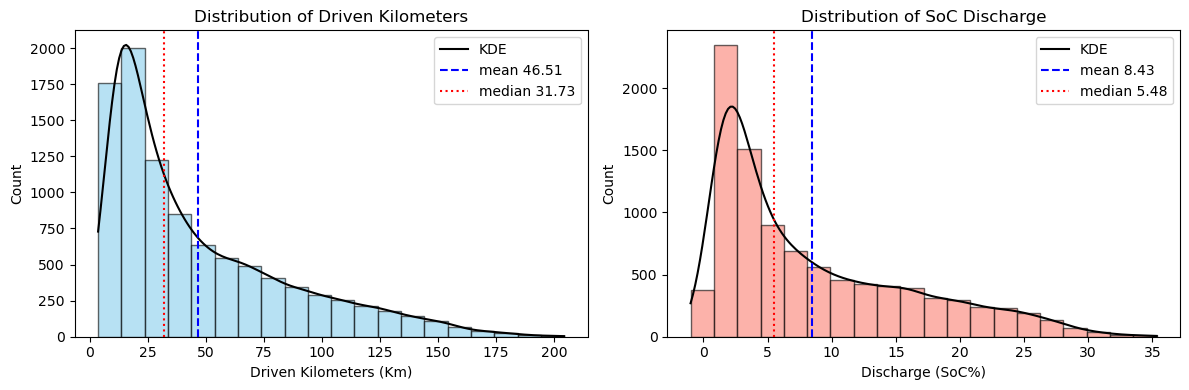

In [33]:
def plot_hist_with_kde(series, ax, color, title, xlabel, bins=20):
    # Ensure numeric and drop NaNs / infs
    y = pd.to_numeric(series, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().values
    if y.size == 0:
        ax.text(0.5, 0.5, "No data", ha='center', va='center')
        ax.set_title(title)
        return

    # Histogram (counts)
    counts, bin_edges, _ = ax.hist(y, bins=bins, density=False,
                                   alpha=0.6, color=color, edgecolor='black')

    # KDE scaled to match histogram counts
    
    try:
        from scipy.stats import gaussian_kde
        kde = gaussian_kde(y)
        x_grid = np.linspace(y.min(), y.max(), 200)
        # scale KDE to counts
        kde_vals = kde(x_grid) * len(y) * (bin_edges[1] - bin_edges[0])
        ax.plot(x_grid, kde_vals, color='k', lw=1.5, label='KDE')
    except ImportError:
        pass  # skip KDE if SciPy not available

    # Mean & median vertical lines
    ax.axvline(y.mean(), color='blue', linestyle='--', label=f'mean {y.mean():.2f}')
    ax.axvline(np.median(y), color='red', linestyle=':', label=f'median {np.median(y):.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_hist_with_kde(trip_data.get('km_driven', pd.Series(dtype=float)), axes[0],
                   color='skyblue', title='Distribution of Driven Kilometers', xlabel='Driven Kilometers (Km)')

plot_hist_with_kde(trip_data.get('discharge', pd.Series(dtype=float)), axes[1],
                   color='salmon', title='Distribution of SoC Discharge', xlabel='Discharge (SoC%)')

plt.tight_layout()
plt.show()

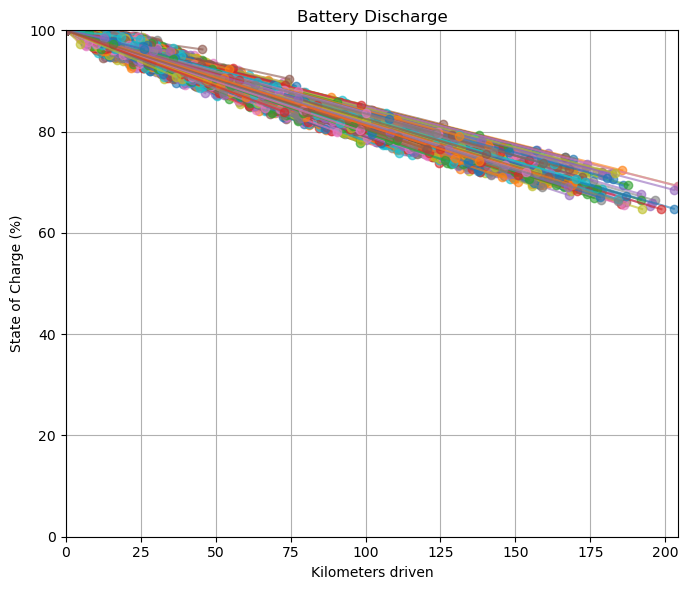

In [34]:
#######################################################
#Visualize delta_soc
trip_data['soc'] = 100
trip_data['end_soc'] = trip_data['soc'] + trip_data['charge'] 


# Max km for x-axis scaling
max_km_driven = trip_data['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


In [35]:
trip_data['discharge_per_km'].describe()

count    9586.000000
mean        0.167459
std         0.054327
min        -0.221607
25%         0.137024
50%         0.177388
75%         0.199947
max         0.538039
Name: discharge_per_km, dtype: float64

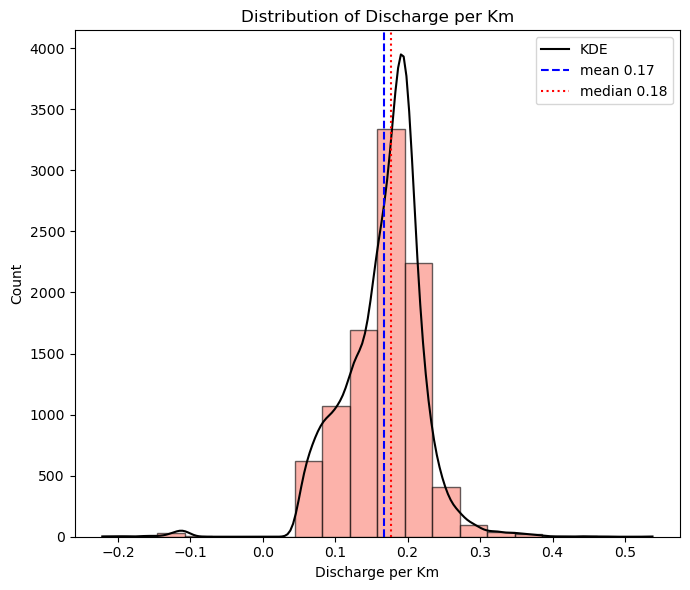

In [36]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='salmon', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

## Original dataset

In [37]:
trip_data_original = pd.read_csv('./datasets/new2_vehicle_2_47174e+18.csv')
trip_data_original = trip_data_original[trip_data_original['event'] == 'trip'].reset_index(drop=True)
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1207 entries, 0 to 1206
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   vin          1207 non-null   float64
 1   timestamp    1207 non-null   object 
 2   end_time     1207 non-null   object 
 3   odo          1207 non-null   float64
 4   end_odo      1207 non-null   float64
 5   soc          1207 non-null   float64
 6   end_soc      1207 non-null   float64
 7   event        1207 non-null   object 
 8   charge_mode  1207 non-null   object 
dtypes: float64(5), object(4)
memory usage: 85.0+ KB


In [38]:
# Remove duplicates
trip_data_original = trip_data_original.drop_duplicates()

# Print how many rows remain
print(f"Number of rows after removing duplicates: {len(trip_data_original)}")

trip_data_original['km_driven'] = trip_data_original['end_odo'] - trip_data_original['odo']
trip_data_original['discharge'] = trip_data_original['soc'] - trip_data_original['end_soc']

print("📊 Statistics on driven km:\n", trip_data_original['km_driven'].describe())
print("\n🔋 Statistics on discharge:\n", trip_data_original['discharge'].describe())

Number of rows after removing duplicates: 1134
📊 Statistics on driven km:
 count    1134.000000
mean       41.036223
std        46.765638
min         0.000000
25%         8.171871
50%        20.304685
75%        64.996092
max       378.187500
Name: km_driven, dtype: float64

🔋 Statistics on discharge:
 count    1134.000000
mean        7.874339
std         9.234552
min        -0.400000
25%         1.200000
50%         3.600000
75%        12.900000
max        74.600000
Name: discharge, dtype: float64


In [39]:
trip_data_original['km_per_perc_of_battery'] = trip_data_original.apply(
    lambda row: row['km_driven'] / row['discharge'] if row['discharge'] != 0 else 0,
    axis=1
)

trip_data_original['discharge_per_km'] = trip_data_original.apply(
    lambda row: row['discharge'] / row['km_driven'] if row['km_driven'] != 0 else 0,
    axis=1
)


In [40]:
MAX_DISCHARGE_PER_KM = 0.9
##########################################################



anomalous_rows_trip = trip_data_original[(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)]
print(f"Number of anamalous rows: {anomalous_rows_trip.shape[0]}")

trip_data_original = trip_data_original[~(trip_data_original['discharge_per_km'] > MAX_DISCHARGE_PER_KM)].reset_index(drop=True)
anomalous_rows_trip.head(len(anomalous_rows_trip ))

Number of anamalous rows: 7


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
16,-2.471740e+18,2021-04-29 19:05:00,2021-04-29 19:16:00,2419.812500,2419.84375,25.8,25.4,trip,0,0.031250,0.4,0.078125,12.800000
33,-2.471740e+18,2021-05-02 16:11:00,2021-05-02 16:53:00,2609.625000,2609.65625,34.1,33.3,trip,0,0.031250,0.8,0.039062,25.600000
55,-2.471740e+18,2021-05-05 17:40:00,2021-05-05 18:48:00,2875.703125,2875.75000,39.6,38.8,trip,0,0.046875,0.8,0.058594,17.066667
269,-2.471740e+18,2021-06-08 18:54:00,2021-06-08 18:56:00,11825.156250,11825.65625,50.5,49.8,trip,0,0.500000,0.7,0.714286,1.400000
446,-2.471740e+18,2021-07-11 19:53:00,2021-07-11 20:06:00,21003.656250,21009.34375,62.0,54.0,trip,0,5.687500,8.0,0.710938,1.406593
512,-2.471740e+18,2021-07-17 23:55:00,2021-07-18 01:05:00,23272.312500,23272.64063,41.9,39.2,trip,0,0.328130,2.7,0.121530,8.228446
788,-2.471740e+18,2021-08-10 15:06:00,2021-08-10 15:08:00,31879.125000,31879.32813,36.0,35.6,trip,0,0.203130,0.4,0.507825,1.969182


In [41]:
# Identify anomalous records with high km per percentage of battery discharge 
############################
MAX_KM_PER_DISCHARGE = 20 #
############################

anomalous_discharge_records = trip_data_original[trip_data_original['km_per_perc_of_battery'] > MAX_KM_PER_DISCHARGE].sort_values(by='km_per_perc_of_battery', ascending=False)
length = anomalous_discharge_records.shape[0]
print(f"Number of anomalous discharge records: {length}")


anomalous_discharge_records.head(length)



Number of anomalous discharge records: 3


,vin,timestamp,end_time,odo,end_odo,soc,end_soc,event,charge_mode,km_driven,discharge,km_per_perc_of_battery,discharge_per_km
535,-2.471740e+18,2021-07-23 00:31:00,2021-07-23 01:14:00,25236.45313,25248.85123,60.0,59.6,trip,0,12.3981,0.4,30.99525,0.032263
596,-2.471740e+18,2021-07-29 20:46:00,2021-07-29 21:00:00,27163.21875,27172.03125,15.2,14.9,trip,0,8.8125,0.3,29.37500,0.034043
521,-2.471740e+18,2021-07-13 00:08:00,2021-07-13 00:21:00,21541.39063,21550.70313,47.8,47.4,trip,0,9.3125,0.4,23.28125,0.042953


In [42]:
trip_data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127 entries, 0 to 1126
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   vin                     1127 non-null   float64
 1   timestamp               1127 non-null   object 
 2   end_time                1127 non-null   object 
 3   odo                     1127 non-null   float64
 4   end_odo                 1127 non-null   float64
 5   soc                     1127 non-null   float64
 6   end_soc                 1127 non-null   float64
 7   event                   1127 non-null   object 
 8   charge_mode             1127 non-null   object 
 9   km_driven               1127 non-null   float64
 10  discharge               1127 non-null   float64
 11  km_per_perc_of_battery  1127 non-null   float64
 12  discharge_per_km        1127 non-null   float64
dtypes: float64(9), object(4)
memory usage: 114.6+ KB


In [43]:
trip_data_original['discharge_per_km'].describe()

count    1127.000000
mean        0.171472
std         0.081386
min        -0.474074
25%         0.151256
50%         0.182416
75%         0.205175
max         0.752941
Name: discharge_per_km, dtype: float64

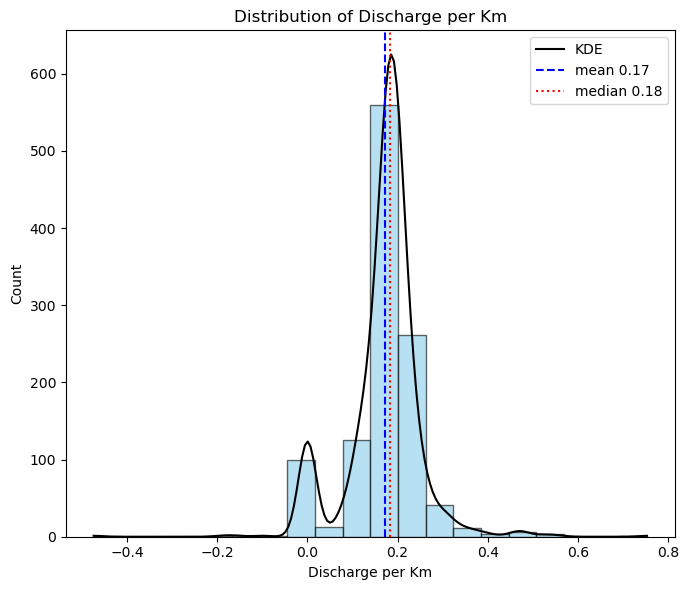

In [44]:
# --- Distribution of Discharge per Km ---
fig, ax = plt.subplots(figsize=(7, 6))

plot_hist_with_kde(trip_data_original.get('discharge_per_km', pd.Series(dtype=float)), ax,
                   color='skyblue', title='Distribution of Discharge per Km', xlabel='Discharge per Km')


plt.tight_layout()
plt.show()

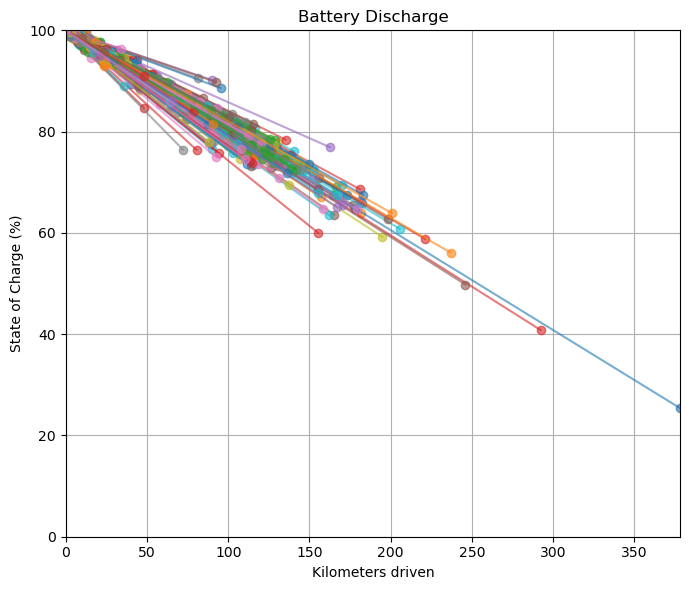

In [45]:
#######################################################
#visualiza delta_soc
trip_data_original['delta_soc'] = trip_data_original['end_soc'] - trip_data_original['soc']
trip_data_original['soc'] = 100
trip_data_original['end_soc'] = trip_data_original['soc'] + trip_data_original['delta_soc'] 



# Max km for x-axis scaling
max_km_driven = trip_data_original['km_driven'].max()

# --- Matplotlib version ---
fig, ax = plt.subplots(figsize=(7, 6))

for _, row in trip_data_original.iterrows():
    x_vals = [0, row['km_driven']]
    y_vals = [row['soc'], row['end_soc']]
    ax.plot(x_vals, y_vals, marker='o', alpha=0.6)

ax.set_title('Battery Discharge')
ax.set_xlabel('Kilometers driven')
ax.set_ylabel('State of Charge (%)')
ax.set_xlim(0, max_km_driven)
ax.set_ylim(0, 100)
ax.grid(True)

plt.tight_layout()
plt.show()


# --- Plotly version ---
colors = px.colors.qualitative.Plotly
fig = go.Figure()

for color_idx, (_, row) in enumerate(trip_data_original.reset_index().iterrows()):
    fig.add_trace(
        go.Scatter(
            x=[0, row['km_driven']],
            y=[row['soc'], row['end_soc']],
            mode='lines+markers',
            opacity=0.5,
            line=dict(color=colors[color_idx % len(colors)], width=2),
            marker=dict(size=6),
            name=f"Trip {row['index']}",
            hovertemplate=(
                f"Trip index: {row['index']}<br>"
                f"SOC start: {row['soc']}%<br>"
                f"SOC end: {row['end_soc']}%<br>"
                f"Km driven: {row['km_driven']} km<br>"
            )
        )
    )

fig.update_xaxes(title_text='Kilometers driven', range=[0, max_km_driven])
fig.update_yaxes(title_text='State of Charge (%)', range=[0, 100])

fig.update_layout(
    title="Battery Discharge",
    height=500,
    width=700,
    showlegend=False,
    hovermode='closest'
)

fig.show()


## Save trip data cleaned

In [46]:
# Save DataFrame
if SAVE:
    trip_data.to_csv(file_path_csv, index=False)

In [47]:
trip_data.head()

,event,charge_mode,duration_minutes,km_driven,charge,id,delta_soc,discharge,avg_speed,km_per_perc_of_battery,discharge_per_km,soc,end_soc
0,0,0,37.226245,17.283895,-3.819808,1,-3.819808,3.819808,27.857597,4.524807,0.221004,100,96.180192
1,0,0,82.138858,35.239328,-7.723593,2,-7.723593,7.723593,25.741284,4.562556,0.219175,100,92.276407
2,0,0,13.227310,10.201922,-0.897837,3,-0.897837,0.897837,46.276630,11.362780,0.088007,100,99.102163
3,0,0,36.760313,25.046932,-2.974316,4,-2.974316,2.974316,40.881478,8.421072,0.118750,100,97.025684
4,0,0,55.845177,23.236380,-4.608045,5,-4.608045,4.608045,24.965143,5.042568,0.198312,100,95.391955


In [48]:
trip_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9586 entries, 0 to 9585
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event                   9586 non-null   int64  
 1   charge_mode             9586 non-null   int64  
 2   duration_minutes        9586 non-null   float64
 3   km_driven               9586 non-null   float64
 4   charge                  9586 non-null   float64
 5   id                      9586 non-null   int64  
 6   delta_soc               9586 non-null   float64
 7   discharge               9586 non-null   float64
 8   avg_speed               9586 non-null   float64
 9   km_per_perc_of_battery  9586 non-null   float64
 10  discharge_per_km        9586 non-null   float64
 11  soc                     9586 non-null   int64  
 12  end_soc                 9586 non-null   float64
dtypes: float64(9), int64(4)
memory usage: 973.7 KB
